# Support Vector Machines (SVM) in Regression Tasks

## Linear SVM Regression

Generate 100 samples with a linear relationship and Gaussian noise. 

In [188]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=622)

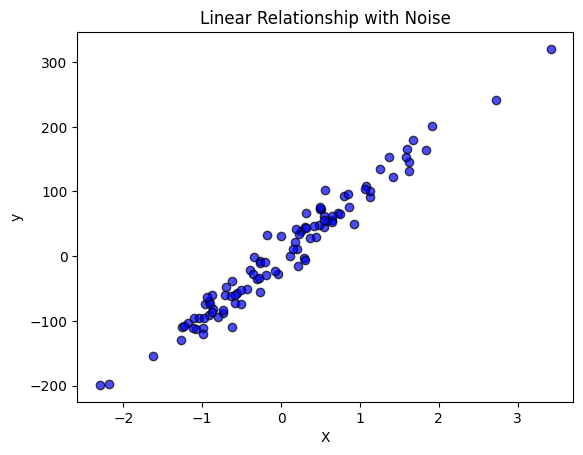

In [189]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue', label='Data Points', edgecolor='black', alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Relationship with Noise")
plt.show()

### SVM Regression Pipeline
StandardScaler normalizes features to zero mean and unit variance—critical for SVMs since they rely on distance metrics. 


In [190]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_reg = Pipeline([('scaler',StandardScaler()), 
                        ('linearsvr', LinearSVR(random_state=622))])

svm_reg.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linearsvr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"epsilon epsilon: float, default=0.0Epsilon parameter in the epsilon-insensitive loss function. Notethat the value of this parameter depends on the scale of the targetvariable y. If unsure, set ``epsilon=0``.",0.0
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.",1.0
,"loss loss: {'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='epsilon_insensitive'Specifies the loss function. The epsilon-insensitive loss(standard SVR) is the L1 loss, while the squared epsilon-insensitiveloss ('squared_epsilon_insensitive') is the L2 loss.",'epsilon_insensitive'


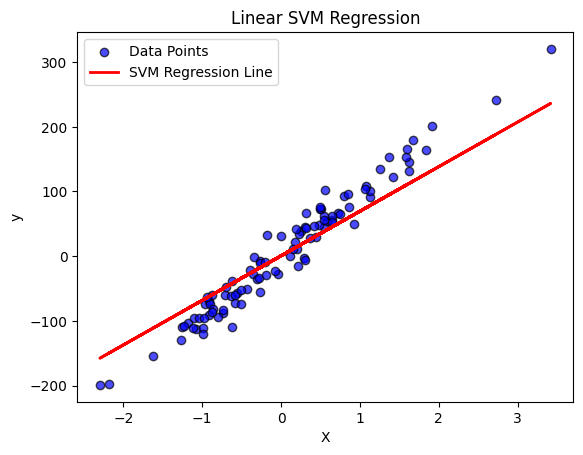

In [191]:
y_pred = svm_reg.predict(X)
plt.scatter(X, y, color='blue', label='Data Points', edgecolor='black', alpha=0.7)
plt.plot(X, y_pred, color='red', label='SVM Regression Line', linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear SVM Regression")
plt.legend()
plt.show()

### Grid Search for Hyperparameter Tuning

The default LinearSVR works reasonably well, but it can be optimized further. 
RandomizedSearchCV samples 50 different hyperparameter combinations across 5-fold cross-validation to find the best settings.

Key parameters: `C` (regularization parameter) and `epsilon` (threshold parameter).

In [192]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

svm_distributions = {'linearsvr__epsilon': uniform(0.01, 0.1),
                     'linearsvr__C': uniform(0.1, 10)}

svm_randomized_search = RandomizedSearchCV(svm_reg, svm_distributions, n_iter = 50, cv = 5, random_state = 622, verbose=1)

svm_randomized_search.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=622))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'linearsvr__C': <scipy.stats....0023A0BD53570>, 'linearsvr__epsilon': <scipy.stats....0023A0BD53500>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` 

In [212]:
svm_randomized_search.best_params_

{'linearsvr__C': np.float64(8.567157187373708),
 'linearsvr__epsilon': np.float64(0.08869315937578615)}

In [193]:
from sklearn.metrics import mean_squared_error

y_search_pred = svm_randomized_search.predict(X)

mse = mean_squared_error(y, y_search_pred)

In [194]:
mse

343.1100412655368

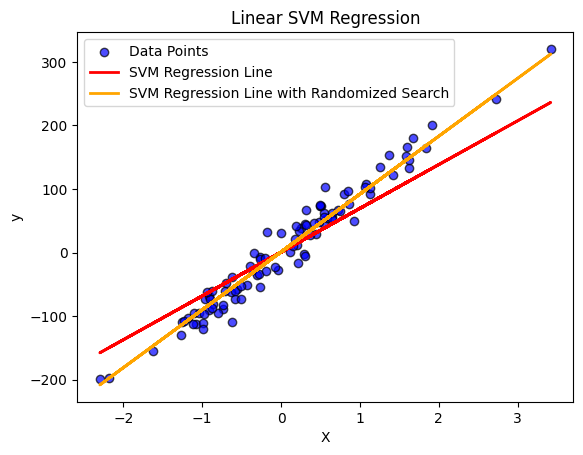

In [195]:
plt.scatter(X, y, color='blue', label='Data Points', edgecolor='black', alpha=0.7)
plt.plot(X, y_pred, color='red', label='SVM Regression Line', linewidth=2)
plt.plot(X, y_search_pred, color='orange', label='SVM Regression Line with Randomized Search', linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear SVM Regression")
plt.legend()
plt.show()

## Polynomial SVM Regression

Let's generate cubic data ($y = 4x^3$ + noise) and use SVR with different kernels to capture complex curves.

In [196]:
import numpy as np

m = 300
np.random.seed(622)

X = 3 * np.random.rand(m, 1) + -3 * np.random.rand(m, 1)
y = 4 * X[:, 0] ** 3 + np.random.randn(m) * 5

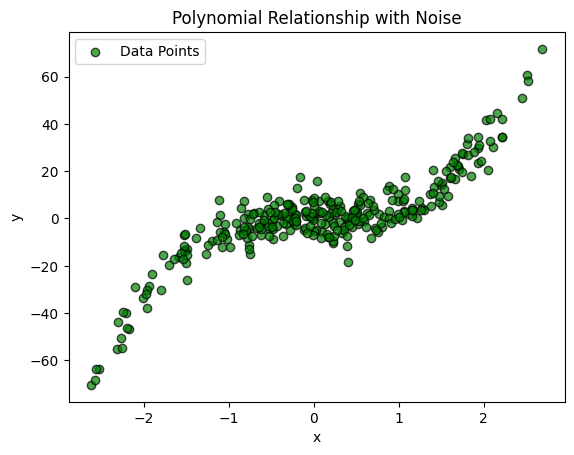

In [197]:
plt.scatter(X, y, color='green', label='Data Points', edgecolor='black', alpha=0.7)
plt.title("Polynomial Relationship with Noise")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [198]:
from sklearn.svm import SVR

svm_poly_reg = Pipeline([('scaler', StandardScaler()),
                         ('svr', SVR())]
                         )


Additional key parameters: `kernel` (type of kernel function), `degree` (degree of the 'poly' kernel function) and `gamma` (parameter that defines how far the influence of a single training example reaches).

In [199]:
from scipy.stats import randint, reciprocal

svm_poly_distributions = {'svr__kernel': ['rbf', 'poly'],
                          'svr__degree': randint(low=2, high = 7),
                            'svr__C': uniform(0.1, 10),
                            'svr__epsilon': uniform(0.01, 1),
                            'svr__gamma': reciprocal(0.01, 10)}

svm_poly_search = RandomizedSearchCV(svm_poly_reg, svm_poly_distributions, n_iter = 50, cv = 5, random_state = 622, verbose=1)

svm_poly_search.fit(X, y)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....0023A0BD5DEC0>, 'svr__degree': <scipy.stats....0023A0BD5DE50>, 'svr__epsilon': <scipy.stats....0023A0BD5DF30>, 'svr__gamma': <scipy.stats....0023A0BD5DFA0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the v

In [200]:
svm_poly_search.best_params_

{'svr__C': np.float64(3.947540295444616),
 'svr__degree': 3,
 'svr__epsilon': np.float64(0.6170168721751469),
 'svr__gamma': np.float64(0.9217962801802557),
 'svr__kernel': 'poly'}

In [201]:
y_pred = svm_poly_search.predict(X)

mse = mean_squared_error(y, y_pred)

In [202]:
mse

30.713102967379722

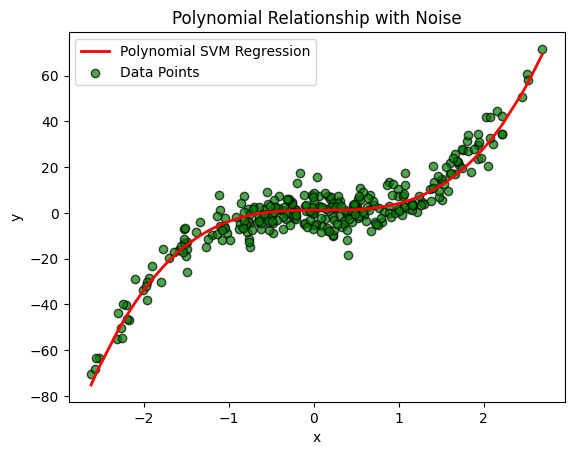

In [203]:
X_sorted = np.sort(X, axis=0)
y_sorted_pred = svm_poly_search.predict(X_sorted)

plt.plot(X_sorted, y_sorted_pred, color='red', label='Polynomial SVM Regression', linewidth=2)
plt.scatter(X, y, color='green', label='Data Points', edgecolor='black', alpha=0.7)
plt.title("Polynomial Relationship with Noise")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

As shown in the figure,  the curve fits the data quite well. The low value of the mean squared error also indicates that the model fits the data effectively. 

In summary, when the data follows a polynomial distribution, the **SVR** method works quite well.

## Non-linear SVM Regression

Let's check whether **SVR** works with non-linear functions such as: $y = 2\sin(5x)\exp(x)$ + noise.

In [204]:
m = 400
np.random.seed(622)

X = 4 * np.random.rand(m, 1) 
y = 2 * np.sin(5 * X[:, 0]) * np.exp(X[:, 0]) + np.random.randn(m) * 9

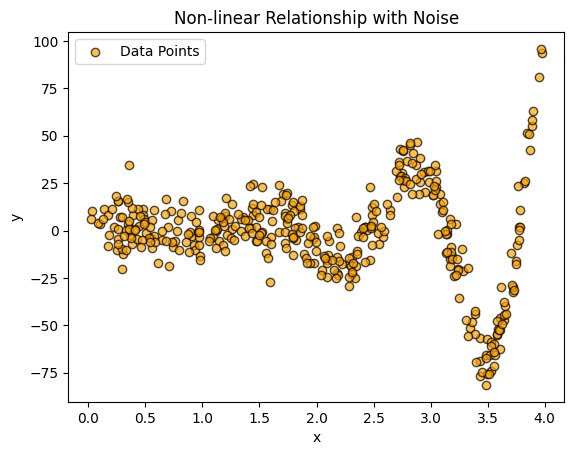

In [205]:
plt.scatter(X, y, color='orange', label='Data Points', edgecolor='black', alpha=0.7)
plt.title("Non-linear Relationship with Noise")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [213]:
svm_nonlinear_reg = Pipeline([('scaler', StandardScaler()),
                         ('svr', SVR(kernel='rbf'))]
                         )


svm_nonlinear_distributions = {'svr__C': randint(low=1, high = 1000),
                            'svr__epsilon': uniform(0.1, 10),
                            'svr__gamma': reciprocal(0.01, 10)}

svm_nonlinear_search = RandomizedSearchCV(svm_nonlinear_reg, svm_nonlinear_distributions, n_iter = 100, cv = 5, random_state = 622, verbose=1)

svm_nonlinear_search.fit(X, y)


Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....0023A0CD21510>, 'svr__epsilon': <scipy.stats....0023A0CD21580>, 'svr__gamma': <scipy.stats....0023A0CD215F0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used 

In [207]:
svm_nonlinear_search.best_params_

{'svr__C': 456,
 'svr__epsilon': np.float64(9.673060481057725),
 'svr__gamma': np.float64(3.25019267298002)}

In [208]:
from sklearn.metrics import mean_absolute_error
y_pred = svm_nonlinear_search.predict(X)

mse = mean_squared_error(y, y_pred)

mae = mean_absolute_error(y, y_pred)

In [209]:
mse

83.62750963602326

In [210]:
mae

7.329172134090581

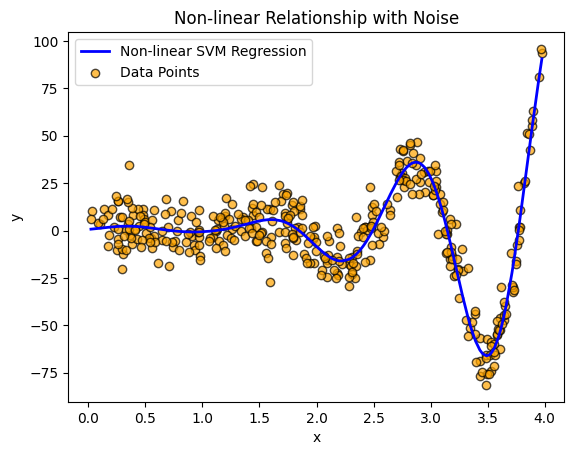

In [211]:
X_sorted = np.sort(X, axis=0)
y_sorted_pred = svm_nonlinear_search.predict(X_sorted)

plt.plot(X_sorted, y_sorted_pred, color='blue', label='Non-linear SVM Regression', linewidth=2)
plt.scatter(X, y, color='orange', label='Data Points', edgecolor='black', alpha=0.7)
plt.title("Non-linear Relationship with Noise")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Even with the non-linear data, SVR can still capture the underlying pattern effectively, as shown in the figure. The mean squared error and mean absolute error are relatively low, indicating a good fit to the data.